# 01 — Data Loading and Preprocessing

**Purpose**: Run the full GPS → pitch → active-players → transport tables pipeline
and save intermediate artefacts to `../data/` so every downstream figure notebook
can load from cache without re-running the heavy pipeline.

## Pipeline
```
S3 GPS parquets
  → DayDataLoader          (src.utils.day_loader)
  → pitch calibration      (src.utils.pitch_calibration)
  → match-phase labelling  (src.utils.match_phases)
  → active-player filter   (src.utils.player_status)
  → position labelling     (local function)
  → run segmentation       (src.utils.trajectory_stats)
  → collective order       (src.utils.collective_stats)
  → hazard intervals       (src.utils.hazard_stats)
  → cache as .parquet      (analysis.levy_paper.util.paper_utils)
```

## Outputs (written to `../data/`)
| File | Contents |
|------|----------|
| `runs_long.parquet` | Per-run statistics (duration, length, speed, order, team) |
| `trajectory_long.parquet` | Frame-level positions and velocities |
| `msd_long.parquet` | MSD decomposition (centroid, relative, player) |
| `df_pmv.parquet` | Polarisation / milling / centroid-velocity time series |
| `centroid_order_runs.parquet` | Run-level collective order summaries |
| `hazard_intervals.parquet` | Age-binned intervals for hazard modelling |

**Run this notebook once per data update; all figure notebooks load from cache.**

## 0. Configuration

Fill in the constants below before running. Everything else is automatic.

In [32]:
import os
from dotenv import load_dotenv
from pathlib import Path

# Load .env before reading any config values
load_dotenv(Path(os.getcwd()).parents[2] / ".env")

# ── CONFIG ────────────────────────────────────────────────────────────────
# Bucket is read from .env (S3_BUCKET) with a fallback for safety
BUCKET        = os.getenv("S3_BUCKET", "ucl-ai-soccormon-dataset")
SOURCE_BASE_A = "objective_TEAM_A"
SOURCE_BASE_B = "objective_team_B"
YEAR          = "2020"
KAMPER_PATH   = str(Path(os.getcwd()).parents[2] / "notebooks" / "kamper.xlsx")
# ─────────────────────────────────────────────────────────────────────────

print("Bucket:      ", BUCKET)
print("Source A:    ", SOURCE_BASE_A)
print("Source B:    ", SOURCE_BASE_B)
print("Kamper path: ", KAMPER_PATH, " exists:", Path(KAMPER_PATH).exists())

Bucket:       ucl-ai-soccormon-dataset
Source A:     objective_TEAM_A
Source B:     objective_team_B
Kamper path:  c:\Users\Daniel\projects\framewave\repos\athlelorian\notebooks\kamper.xlsx  exists: False


In [33]:
import sys, os, json
from pathlib import Path

# ── repo root on path ──────────────────────────────────────────────────────
_HERE = Path(os.getcwd())
_REPO = _HERE.parents[2]          # notebooks/ -> levy_paper/ -> analysis/ -> repo root
if str(_REPO) not in sys.path:
    sys.path.insert(0, str(_REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
load_dotenv(_REPO / ".env")

from analysis.levy_paper.util.paper_utils import (
    configure_paper_plotting, save_cache,
    THETA_DEG, ACTIVE_DEPTH_M, ACTIVATE_S, BENCH_OFF_S, DATA_DIR,
)
configure_paper_plotting()
print("Repo root:", _REPO)
print("Cache dir:", DATA_DIR)

Repo root: c:\Users\Daniel\projects\framewave\repos\athlelorian
Cache dir: C:\Users\Daniel\projects\framewave\repos\athlelorian\analysis\levy_paper\data


## 1. Connect to S3 and Set Up Index

Reads AWS credentials from `.env` (AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY).

In [34]:
from src.utils.data_access import S3DataAccess
from src.utils.match_loader import MatchesLoader
from src.utils.player_utils import PlayerNameMapper
from src.utils.day_loader import DayDataLoader
from src.utils.match_index import SoccermonMatchIndex

# S3 filesystem
s3 = S3DataAccess()          # reads AWS_ACCESS_KEY_ID / AWS_SECRET_ACCESS_KEY from .env
fs = s3.fs

# Match schedule
matches = MatchesLoader(KAMPER_PATH).load()
print(f"Loaded {len(matches)} matches from schedule")
display(matches.head())

# Player name mapper
mapper = PlayerNameMapper()

# Day loader (handles Norway timestamps + player name mapping)
day_loader = DayDataLoader(fs=fs, mapper=mapper)

# Match index: ties S3 day folders to kamper schedule
index = SoccermonMatchIndex(
    fs=fs,
    bucket=BUCKET,
    day_loader=day_loader,
    matches=matches,
    year=YEAR,
    source_base_A=SOURCE_BASE_A,
    source_base_B=SOURCE_BASE_B,
)

# infer() scans S3 dates and matches them to club names
result = index.infer()
print("\nInferred clubs:")
for k, v in result.items():
    print(f"  {k}: {v}")

Loaded 90 matches from schedule


,date,time,home,away,score
0,2020-07-03,19:45,Rosenborg,LSK Kvinner,1-1
1,2020-07-04,11:30,Røa Fotball Elite,Arna-Bjørnar,0-1
2,2020-07-04,13:00,Avaldsnes,Lyn,5-2
3,2020-07-04,14:00,Sandviken,Vålerenga,3-2
4,2020-07-05,15:00,Klepp,Kolbotn,0-0



Inferred clubs:
  source_A_club: rosenborg
  source_B_club: vålerenga
  A_overlap: 17
  B_overlap: 18
  n_head_to_head: 2


## 2. Match Selection

- **Single-team matches** (`source_key="A"`): used for within-team transport analysis.
- **Head-to-head fixtures**: both teams tracked simultaneously — used for notebook 07.

> **TODO**: Add 2021 data to S3 once uploaded. Current data is 2020 only.
> Target: 4 H2H fixtures across 2 years.

In [35]:
single_matches = index.matches_for_source("A")   # "A" or "B"
h2h_fixtures   = index.head_to_head()            # fixtures where both teams have data

print(f"Single-team matches (source A): {len(single_matches)}")
print(f"Head-to-head fixtures:          {len(h2h_fixtures)}")
display(single_matches[["date", "home", "away"]].head())

Single-team matches (source A): 18
Head-to-head fixtures:          2


,date,home,away
0,2020-07-03,Rosenborg,LSK Kvinner
1,2020-07-11,Lyn,Rosenborg
2,2020-07-19,Rosenborg,Kolbotn
3,2020-07-25,Arna-Bjørnar,Rosenborg
4,2020-08-02,Rosenborg,Klepp


## 3. Load Pitch Registry

In [36]:
_pitch_json = _REPO / "notebooks" / "toppserien_pitches.json"
with open(_pitch_json) as f:
    pitch_registry = json.load(f)

print(f"Loaded {len(pitch_registry)} stadiums: {list(pitch_registry.keys())}")

Loaded 10 stadiums: ['Arna Idrettspark', 'Avaldsnes Idrettssenter', 'Klepp Stadion', 'Sofiemyr stadion', 'LSK-hallen', 'KringsjÃ¥ kunstgress', 'RÃ¸a kunstgress', 'Koteng Arena', 'Stemmemyren', 'Intility Arena']


## 4. GPS Loading, Pitch Calibration, and Active-Player Filtering

For each match:
1. Load raw GPS from S3 (1 Hz downsampled).
2. Calibrate pitch polygon → pitch-aligned (x_m, y_m).
3. Label match phases and keep only 1H / 2H.
4. Label and filter to active players.

In [37]:
from src.utils.pitch_calibration import calibrate_pitch_from_df, attach_xy_from_pitch
from src.utils.match_phases import label_match_phases
from src.utils.player_status import label_active_players
from src.utils.match_index import build_day_prefix
import traceback

if len(single_matches) > 0:
    _sample_date = str(single_matches.iloc[0]["date"])
    _sample_path = build_day_prefix(BUCKET, SOURCE_BASE_A, _sample_date)
    print(f"S3 path for first match: s3://{_sample_path}")
    print(f"BUCKET = {BUCKET!r}")
    print()

all_matches_active = {}

for _, row in single_matches.iterrows():
    date_str = str(row["date"])
    print(f"Loading {date_str} … ", end="")

    try:
        df_raw = index.load_team_match(row, source_key="A", one_hz=True)

        # calibrate_pitch_from_df returns (stadium_name, center_latlon, R, pitch_xy_rot)
        # pitch_xy_rot is needed by label_active_players to compute depth from pitch edges
        stadium_name, center_latlon, R, pitch_xy = calibrate_pitch_from_df(df_raw, pitch_registry)
        df_xy = attach_xy_from_pitch(df_raw, center_latlon, R, stadium_name=stadium_name)

        kickoff_time = pd.Timestamp(f"{row['date']} {row['time']}")
        df_xy = label_match_phases(df_xy, kickoff_time=kickoff_time)
        df_play = df_xy.loc[df_xy["match_phase"].isin(["1H", "2H"])].copy()

        # pitch_xy is the list of rotated (x,y) polygon corners
        df_play = label_active_players(df_play, pitch_xy=pitch_xy,
                                       active_depth_m=ACTIVE_DEPTH_M,
                                       activate_s=ACTIVATE_S,
                                       bench_off_s=BENCH_OFF_S)
        df_active = df_play.loc[df_play["player_status"] == "active"].copy()
        df_active["match_id"] = date_str
        df_active["team"] = index.club_A

        all_matches_active[date_str] = df_active
        print(f"{len(df_active):,} active frames, {df_active['player_name'].nunique()} players")

    except Exception:
        print("FAILED")
        traceback.print_exc()

if not all_matches_active:
    raise RuntimeError(
        f"\nNo matches loaded. BUCKET={BUCKET!r}\n"
        "Check tracebacks above for the root cause."
    )

print(f"\nLoaded {len(all_matches_active)} matches successfully.")

S3 path for first match: s3://ucl-ai-soccormon-dataset/data/objective_TEAM_A_2020/2020-07/2020-07-03
BUCKET = 'ucl-ai-soccormon-dataset'

Loading 2020-07-03 … [calibrate] Stadium='Koteng Arena', centre=(63.445110, 10.451929), first-sample distance ≈ 20.0 m
63,881 active frames, 18 players
Loading 2020-07-11 … [calibrate] Stadium='KringsjÃ¥ kunstgress', centre=(59.965420, 10.727010), first-sample distance ≈ 23.3 m
59,533 active frames, 16 players
Loading 2020-07-19 … [calibrate] Stadium='Koteng Arena', centre=(63.445110, 10.451929), first-sample distance ≈ 30.6 m
72,054 active frames, 20 players
Loading 2020-07-25 … [calibrate] Stadium='Arna Idrettspark', centre=(60.425694, 5.471722), first-sample distance ≈ 9.4 m
56,101 active frames, 14 players
Loading 2020-08-02 … [calibrate] Stadium='Koteng Arena', centre=(63.445110, 10.451929), first-sample distance ≈ 28.9 m
60,193 active frames, 16 players
Loading 2020-08-08 … [calibrate] Stadium='Stemmemyren', centre=(60.425770, 5.305447), first-

Traceback (most recent call last):
  File "C:\Users\Daniel\AppData\Local\Temp\ipykernel_14908\391746355.py", line 21, in <module>
    df_raw = index.load_team_match(row, source_key="A", one_hz=True)
  File "C:\Users\Daniel\projects\framewave\repos\athlelorian\src\utils\match_index.py", line 340, in load_team_match
    return self.load_day_source(
           ~~~~~~~~~~~~~~~~~~~~^
        date_str=date_str,
        ^^^^^^^^^^^^^^^^^^
    ...<2 lines>...
        max_files=max_files,
        ^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Users\Daniel\projects\framewave\repos\athlelorian\src\utils\match_index.py", line 288, in load_day_source
    df = self.day_loader.load_day_1hz(prefix)
  File "C:\Users\Daniel\projects\framewave\repos\athlelorian\src\utils\day_loader.py", line 149, in load_day_1hz
    parquet_files = self._list_parquets(path, max_files=max_files)
  File "C:\Users\Daniel\projects\framewave\repos\athlelorian\src\utils\day_loader.py", line 90, in _list_parquets
    files = self.

[calibrate] Stadium='Koteng Arena', centre=(63.445110, 10.451929), first-sample distance ≈ 29.6 m
57,246 active frames, 17 players
Loading 2020-09-26 … [calibrate] Stadium='Sofiemyr stadion', centre=(59.800535, 10.818762), first-sample distance ≈ 111.1 m
57,362 active frames, 13 players
Loading 2020-10-04 … [calibrate] Stadium='Koteng Arena', centre=(63.445110, 10.451929), first-sample distance ≈ 24.6 m
57,736 active frames, 13 players
Loading 2020-10-18 … [calibrate] Stadium='Intility Arena', centre=(59.917798, 10.806929), first-sample distance ≈ 67.5 m
68,002 active frames, 16 players
Loading 2020-11-01 … [calibrate] Stadium='Koteng Arena', centre=(63.445110, 10.451929), first-sample distance ≈ 22.3 m
57,688 active frames, 15 players
Loading 2020-11-07 … [calibrate] Stadium='Koteng Arena', centre=(63.445110, 10.451929), first-sample distance ≈ 32.0 m
64,706 active frames, 19 players
Loading 2020-12-06 … [calibrate] Stadium='Klepp Stadion', centre=(58.775477, 5.633191), first-sample d

## 5. Player Position Labelling

Addresses **TODO #1**: add positional labels based on distance to own goal at kickoff.

Each player is assigned a coarse label (GK/DEF, DEF/MID, MID/FWD, FWD) by
quartile of their median depth (x_m) in the first few frames of the first half.

In [38]:
from sklearn.cluster import KMeans

def assign_position_labels_smart(
    df_active: pd.DataFrame,
    n_kickoff_frames: int = 10,
) -> pd.DataFrame:
    """
    Position labelling via 1-D k-means (k=3) on kickoff depth, per team.

      GK  = player with most extreme x from pitch centre (furthest back).
      DEF / MID / FWD = k-means(k=3) on the remaining outfield players,
                        cluster centres sorted from own goal outward.

    Works for single-team and H2H — each team processed independently,
    so opposite goal directions don't interfere.
    Substitutes not present at kickoff get label 'Unknown'.
    """
    phase_col = "match_phase" if "match_phase" in df_active.columns else "phase"

    ko = (
        df_active.loc[df_active[phase_col] == "1H"]
        .sort_values("timestamp")
        .groupby("player_name")
        .head(n_kickoff_frames)
    )

    def _label_team(depths: pd.Series) -> dict[str, str]:
        """depths: Series[player_name -> median_x_m]."""
        if len(depths) < 4:
            return {n: "Unknown" for n in depths.index}

        d      = depths.values
        names  = depths.index.tolist()

        # GK = most extreme player from pitch centre
        team_median = float(np.median(d))
        gk_idx  = int(np.argmin(d) if team_median < 0 else np.argmax(d))
        gk_name = names[gk_idx]

        out_idx    = [i for i in range(len(d)) if i != gk_idx]
        out_names  = [names[i] for i in out_idx]
        out_depths = d[out_idx].reshape(-1, 1)

        n_clusters = min(3, len(out_names))   # can't have more clusters than players
        km = KMeans(n_clusters=n_clusters, n_init=10, random_state=0)
        km.fit(out_depths)

        # Sort cluster centres from own goal outward → DEF, MID, FWD
        centres = km.cluster_centers_.flatten()
        if team_median < 0:
            order = np.argsort(centres)           # ascending  (own goal at negative x)
        else:
            order = np.argsort(centres)[::-1]     # descending (own goal at positive x)

        line_names = ["DEF", "MID", "FWD"]
        cluster_to_label = {int(order[i]): line_names[i] for i in range(n_clusters)}

        result = {gk_name: "GK"}
        for nm, cl in zip(out_names, km.labels_):
            result[nm] = cluster_to_label[int(cl)]
        return result

    pos_map: dict[str, str] = {}

    if "team" in ko.columns:
        for _, grp in ko.groupby("team"):
            pos_map.update(_label_team(grp.groupby("player_name")["x_m"].median()))
    else:
        pos_map.update(_label_team(ko.groupby("player_name")["x_m"].median()))

    out = df_active.copy()
    out["position_label"] = out["player_name"].map(pos_map).fillna("Unknown")
    return out


assert all_matches_active, "all_matches_active is empty — did the loading cell fail?"

for mid in list(all_matches_active.keys()):
    all_matches_active[mid] = assign_position_labels_smart(all_matches_active[mid])

sample = next(iter(all_matches_active.values()))
print(sample.groupby("position_label")["player_name"].nunique())

position_label
DEF    7
FWD    6
GK     1
MID    4
Name: player_name, dtype: int64


## 6. Transport Tables

Addresses **TODO #3**: compile statistics from multiple matches.
This loops over all loaded matches and concatenates into unified tables.

In [39]:
from src.utils.trajectory_stats import build_transport_tables_from_active_v2

all_transport = {}

for match_id, df_active in all_matches_active.items():
    print(f"Building transport tables: {match_id} … ", end="")
    transport = build_transport_tables_from_active_v2(
        df_active,
        theta_deg=THETA_DEG,
    )
    all_transport[match_id] = transport
    print("done")

# Concatenate across matches — keep match_id for per-match breakdowns
runs_long       = pd.concat([t["runs_long"]       for t in all_transport.values()], ignore_index=True)
trajectory_long = pd.concat([t["trajectory_long"] for t in all_transport.values()], ignore_index=True)
msd_long        = pd.concat([t["msd_long"]        for t in all_transport.values()], ignore_index=True)

print(f"\nRuns: {len(runs_long):,} | Frames: {len(trajectory_long):,}")
print("Columns in runs_long:", runs_long.columns.tolist())

Building transport tables: 2020-07-03 … done
Building transport tables: 2020-07-11 … done
Building transport tables: 2020-07-19 … done
Building transport tables: 2020-07-25 … done
Building transport tables: 2020-08-02 … done
Building transport tables: 2020-08-08 … done
Building transport tables: 2020-08-16 … done
Building transport tables: 2020-08-22 … done
Building transport tables: 2020-08-26 … done
Building transport tables: 2020-08-30 … done
Building transport tables: 2020-09-12 … done
Building transport tables: 2020-09-26 … done
Building transport tables: 2020-10-04 … done
Building transport tables: 2020-10-18 … done
Building transport tables: 2020-11-01 … done
Building transport tables: 2020-11-07 … done
Building transport tables: 2020-12-06 … done

Runs: 707,556 | Frames: 2,113,672
Columns in runs_long: ['match_id', 'match_phase', 'team', 'source_key', 'track_type', 'track_entity_uid', 'track_uid', 'run_uid', 'player_name', 'path_uid', 'run_id', 't_start', 't_end', 'duration_s',

## 7. Collective Order Tables

Compute polarisation p(t), milling m(t), and centroid velocity v_c(t).

Three order measures per centroid run:
- `p_mean`  — retrospective mean (descriptive only — **do not use as predictor**)
- `p_start` — polarisation at run start (causal covariate)
- `p_early_3s` — mean over first 3 s (causal covariate)

In [40]:
from src.utils.collective_stats import build_collective_order_tables_from_transport
from analysis.levy_paper.util.paper_utils import assign_order_state, STATE_BOUNDS, STATE_LABELS

all_pmv           = {}
all_centroid_ord  = {}

for match_id, transport in all_transport.items():
    df_pmv_m, centroid_order_runs_m = build_collective_order_tables_from_transport(transport)
    df_pmv_m["match_id"]           = match_id
    centroid_order_runs_m["match_id"] = match_id
    all_pmv[match_id]           = df_pmv_m
    all_centroid_ord[match_id]  = centroid_order_runs_m

df_pmv            = pd.concat(all_pmv.values(), ignore_index=True)
centroid_ord_runs = pd.concat(all_centroid_ord.values(), ignore_index=True)

# Assign order state labels from p_mean (descriptive)
centroid_ord_runs["order_state"] = assign_order_state(
    centroid_ord_runs["p_mean"],
    bounds=STATE_BOUNDS,
    labels=STATE_LABELS,
)

print("Order state counts:")
print(centroid_ord_runs["order_state"].value_counts())

Team=rosenborg | finite p_mean: 1196 / 1196
  q1=0.425, q2=0.643
Team=rosenborg | finite p_mean: 1090 / 1090
  q1=0.457, q2=0.698
Team=rosenborg | finite p_mean: 944 / 944
  q1=0.377, q2=0.543
Team=rosenborg | finite p_mean: 970 / 970
  q1=0.494, q2=0.715
Team=rosenborg | finite p_mean: 1051 / 1051
  q1=0.415, q2=0.639
Team=rosenborg | finite p_mean: 1171 / 1171
  q1=0.424, q2=0.673
Team=rosenborg | finite p_mean: 1053 / 1053
  q1=0.453, q2=0.659
Team=rosenborg | finite p_mean: 1071 / 1071
  q1=0.414, q2=0.640
Team=rosenborg | finite p_mean: 1025 / 1025
  q1=0.447, q2=0.669
Team=rosenborg | finite p_mean: 1002 / 1002
  q1=0.429, q2=0.661
Team=rosenborg | finite p_mean: 1064 / 1064
  q1=0.391, q2=0.598
Team=rosenborg | finite p_mean: 1001 / 1001
  q1=0.484, q2=0.704
Team=rosenborg | finite p_mean: 1084 / 1084
  q1=0.442, q2=0.672
Team=rosenborg | finite p_mean: 1164 / 1164
  q1=0.358, q2=0.556
Team=rosenborg | finite p_mean: 959 / 959
  q1=0.448, q2=0.670
Team=rosenborg | finite p_mean:

## 8. Hazard Intervals

Discretise each run into 1-s age bins with event indicators and order state.

In [41]:
from src.utils.hazard_stats import build_centroid_hazard_intervals

all_haz = {}
for match_id, transport in all_transport.items():
    df_pmv_m = all_pmv[match_id]
    haz = build_centroid_hazard_intervals(transport, df_pmv_m)
    haz["match_id"] = match_id
    all_haz[match_id] = haz

hazard_intervals = pd.concat(all_haz.values(), ignore_index=True)
print(f"Hazard intervals: {len(hazard_intervals):,}  |  events: {hazard_intervals['event'].sum():,}")
print("Columns:", hazard_intervals.columns.tolist())

Team=rosenborg | finite p_group: 5305 / 5305
  q1=0.540, q2=0.776
hazard_intervals: (5304, 25)
events: 1196
runs: 1196
Team=rosenborg | finite p_group: 5328 / 5328
  q1=0.572, q2=0.825
hazard_intervals: (5328, 25)
events: 1090
runs: 1090
Team=rosenborg | finite p_group: 5308 / 5308
  q1=0.458, q2=0.683
hazard_intervals: (5307, 25)
events: 944
runs: 944
Team=rosenborg | finite p_group: 5169 / 5169
  q1=0.610, q2=0.853
hazard_intervals: (5167, 25)
events: 970
runs: 970
Team=rosenborg | finite p_group: 5193 / 5193
  q1=0.536, q2=0.784
hazard_intervals: (5192, 25)
events: 1051
runs: 1051
Team=rosenborg | finite p_group: 5286 / 5286
  q1=0.577, q2=0.852
hazard_intervals: (5284, 25)
events: 1171
runs: 1171
Team=rosenborg | finite p_group: 5326 / 5326
  q1=0.565, q2=0.795
hazard_intervals: (5325, 25)
events: 1053
runs: 1053
Team=rosenborg | finite p_group: 5287 / 5287
  q1=0.536, q2=0.790
hazard_intervals: (5286, 25)
events: 1071
runs: 1071
Team=rosenborg | finite p_group: 5328 / 5328
  q1=0.

## 9. Head-to-Head Data (for Notebook 07)

Load both teams for head-to-head fixtures and save separate PMV tables.
Skip silently if no H2H fixtures are available.

In [42]:
if len(h2h_fixtures) == 0:
    print("No head-to-head fixtures found — skipping H2H caches.")
else:
    h2h_pmv_A_parts = []
    h2h_pmv_B_parts = []

    for _, row in h2h_fixtures.iterrows():
        date_str = str(row["date"])
        kickoff_time = pd.Timestamp(f"{row['date']} {row['time']}")
        print(f"H2H {date_str} … ", end="")
        try:
            # Team A
            df_A = index.load_team_match(row, source_key="A", one_hz=True)
            _, c_A, R_A, pitch_xy_A = calibrate_pitch_from_df(df_A, pitch_registry)
            df_A_xy = attach_xy_from_pitch(df_A, c_A, R_A)
            df_A_xy = label_match_phases(df_A_xy, kickoff_time=kickoff_time)
            df_A_play = df_A_xy.loc[df_A_xy["match_phase"].isin(["1H", "2H"])].copy()
            df_A_play = label_active_players(df_A_play, pitch_xy=pitch_xy_A,
                                             active_depth_m=ACTIVE_DEPTH_M,
                                             activate_s=ACTIVATE_S, bench_off_s=BENCH_OFF_S)
            df_A_active = df_A_play.loc[df_A_play["player_status"] == "active"].copy()
            df_A_active["match_id"] = date_str

            # Team B
            df_B = index.load_team_match(row, source_key="B", one_hz=True)
            _, c_B, R_B, pitch_xy_B = calibrate_pitch_from_df(df_B, pitch_registry)
            df_B_xy = attach_xy_from_pitch(df_B, c_B, R_B)
            df_B_xy = label_match_phases(df_B_xy, kickoff_time=kickoff_time)
            df_B_play = df_B_xy.loc[df_B_xy["match_phase"].isin(["1H", "2H"])].copy()
            df_B_play = label_active_players(df_B_play, pitch_xy=pitch_xy_B,
                                             active_depth_m=ACTIVE_DEPTH_M,
                                             activate_s=ACTIVATE_S, bench_off_s=BENCH_OFF_S)
            df_B_active = df_B_play.loc[df_B_play["player_status"] == "active"].copy()
            df_B_active["match_id"] = date_str

            tr_A = build_transport_tables_from_active_v2(df_A_active, theta_deg=THETA_DEG)
            tr_B = build_transport_tables_from_active_v2(df_B_active, theta_deg=THETA_DEG)

            pmv_A, _ = build_collective_order_tables_from_transport(tr_A)
            pmv_B, _ = build_collective_order_tables_from_transport(tr_B)
            pmv_A["match_id"] = date_str
            pmv_B["match_id"] = date_str

            h2h_pmv_A_parts.append(pmv_A)
            h2h_pmv_B_parts.append(pmv_B)
            print("done")

        except Exception:
            print("FAILED")
            traceback.print_exc()

    if h2h_pmv_A_parts:
        save_cache(pd.concat(h2h_pmv_A_parts, ignore_index=True), "df_pmv_teamA")
        save_cache(pd.concat(h2h_pmv_B_parts, ignore_index=True), "df_pmv_teamB")
        print("H2H caches saved.")

H2H 2020-08-16 … [calibrate] Stadium='Koteng Arena', centre=(63.445110, 10.451929), first-sample distance ≈ 32.7 m
[calibrate] Stadium='Koteng Arena', centre=(63.445110, 10.451929), first-sample distance ≈ 22.2 m
Team=rosenborg | finite p_mean: 1053 / 1053
  q1=0.453, q2=0.659
Team=vålerenga | finite p_mean: 1025 / 1025
  q1=0.497, q2=0.724
done
H2H 2020-10-18 … [calibrate] Stadium='Intility Arena', centre=(59.917798, 10.806929), first-sample distance ≈ 67.5 m
[calibrate] Stadium='Intility Arena', centre=(59.917798, 10.806929), first-sample distance ≈ 35.1 m
Team=rosenborg | finite p_mean: 1164 / 1164
  q1=0.358, q2=0.556
Team=vålerenga | finite p_mean: 1026 / 1026
  q1=0.404, q2=0.631
done
H2H caches saved.


## 10. Save All Caches

In [43]:
artefacts = {
    "runs_long":           runs_long,
    "trajectory_long":     trajectory_long,
    "msd_long":            msd_long,
    "df_pmv":              df_pmv,
    "centroid_order_runs": centroid_ord_runs,
    "hazard_intervals":    hazard_intervals,
}

for name, df in artefacts.items():
    path = save_cache(df, name)
    print(f"  {name:30s}  ({len(df):,} rows)  ->  {path.name}")

print("\nAll caches saved. Run downstream figure notebooks.")

  runs_long                       (707,556 rows)  ->  runs_long.parquet
  trajectory_long                 (2,113,672 rows)  ->  trajectory_long.parquet
  msd_long                        (120,016 rows)  ->  msd_long.parquet
  df_pmv                          (89,947 rows)  ->  df_pmv.parquet
  centroid_order_runs             (18,021 rows)  ->  centroid_order_runs.parquet
  hazard_intervals                (89,932 rows)  ->  hazard_intervals.parquet

All caches saved. Run downstream figure notebooks.


## 11. Quick Diagnostic Plots

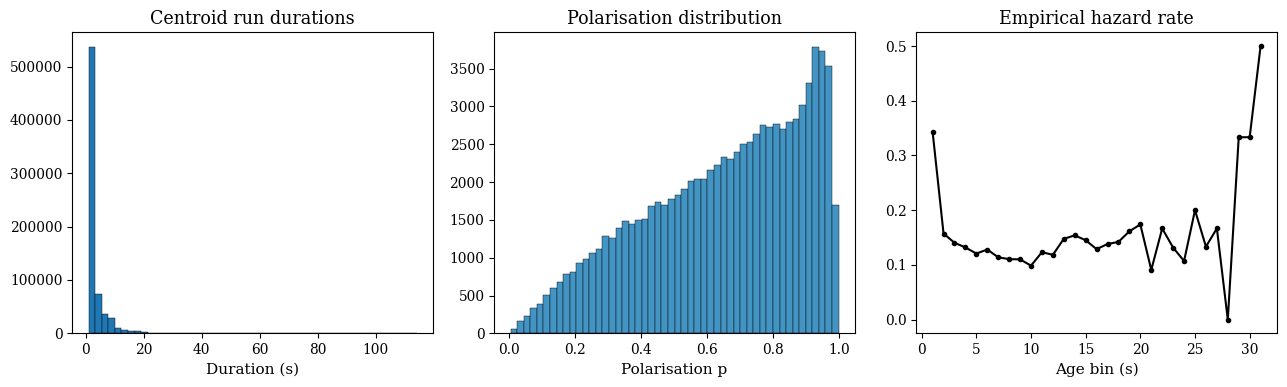


Cache summary:
  runs_long:           707,556 rows,  cols: ['match_id', 'match_phase', 'team', 'source_key', 'track_type', 'track_entity_uid', 'track_uid', 'run_uid', 'player_name', 'path_uid', 'run_id', 't_start', 't_end', 'duration_s', 'run_length_m', 'v_mean_mps']
  hazard_intervals:    89,932 rows,  cols: ['match_id', 'team', 'source_key', 'match_phase', 'track_uid', 'run_uid', 't_run_start', 't_run_end', 't0', 't1', 't_mid', 'age_start_s', 'age_mid_s', 'age_end_s', 'dt_s', 'event', 'run_duration_s', 'run_length_m', 'run_v_mean_mps', 'p_group', 'm_group', 'v_group_mps', 'p_state_current', 'p_state_q1', 'p_state_q2']


In [45]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

centroid_runs_diag = runs_long.loc[runs_long["entity"] == "centroid"] if "entity" in runs_long.columns else runs_long
axes[0].hist(centroid_runs_diag["duration_s"].clip(upper=120), bins=50, edgecolor="k", lw=0.3)
axes[0].set_xlabel("Duration (s)"); axes[0].set_title("Centroid run durations")

axes[1].hist(df_pmv["p_group"].dropna(), bins=50, edgecolor="k", lw=0.3, color="#4393c3")
axes[1].set_xlabel("Polarisation p"); axes[1].set_title("Polarisation distribution")

# age_mid_s is the correct column name (not age_bin)
haz_diag = (
    hazard_intervals
    .groupby(pd.cut(hazard_intervals["age_mid_s"], bins=range(0, 121, 2)))["event"]
    .agg(events="sum", at_risk="count")
    .assign(rate=lambda d: d["events"] / d["at_risk"].clip(lower=1))
)
axes[2].plot(range(1, len(haz_diag) + 1), haz_diag["rate"].values, "k-o", ms=3)
axes[2].set_xlabel("Age bin (s)"); axes[2].set_title("Empirical hazard rate")

plt.tight_layout()
plt.show()

print("\nCache summary:")
print(f"  runs_long:           {len(runs_long):,} rows,  cols: {runs_long.columns.tolist()}")
print(f"  hazard_intervals:    {len(hazard_intervals):,} rows,  cols: {hazard_intervals.columns.tolist()}")